In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

In [2]:
# Load the MNIST dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


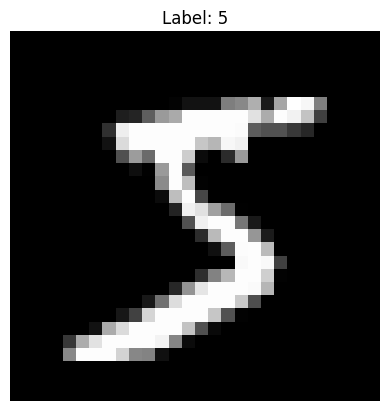

In [4]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [5]:
# Normalize pixel values

X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


In [6]:
print("Minimum value:", X_train.min())
print("Maximum value:", X_train.max())

Minimum value: 0.0
Maximum value: 1.0


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.9607 - loss: 0.1301 - val_accuracy: 0.9847 - val_loss: 0.0467
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9863 - loss: 0.0442 - val_accuracy: 0.9887 - val_loss: 0.0340
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9902 - loss: 0.0305 - val_accuracy: 0.9875 - val_loss: 0.0355
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9934 - loss: 0.0211 - val_accuracy: 0.9897 - val_loss: 0.0308
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9944 - loss: 0.0165 - val_accuracy: 0.9888 - val_loss: 0.0396


In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9888 - loss: 0.0396
Test Loss: 0.039584074169397354
Test Accuracy: 0.9887999892234802


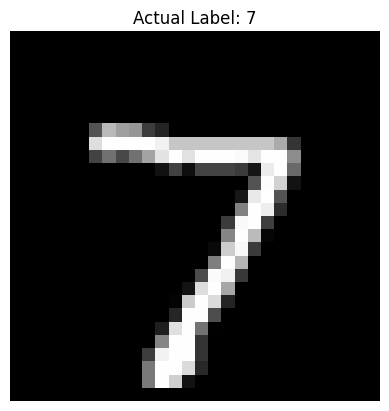

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Predicted Digit: 7


In [10]:
import numpy as np
import matplotlib.pyplot as plt

index = 0

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title("Actual Label: {}".format(y_test[index]))
plt.axis('off')
plt.show()

prediction = model.predict(X_test[index].reshape(1,28,28,1))

print("Predicted Digit:", np.argmax(prediction))

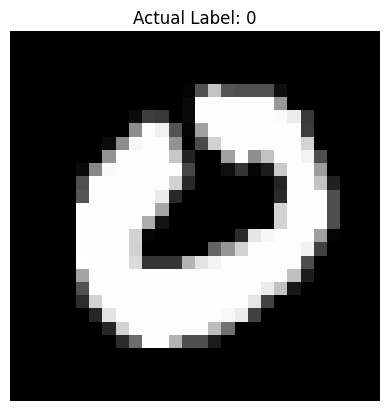

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Digit: 0


In [11]:
import numpy as np
import matplotlib.pyplot as plt

index = 25  # Change this number

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title("Actual Label: {}".format(y_test[index]))
plt.axis('off')
plt.show()

prediction = model.predict(X_test[index].reshape(1,28,28,1))

print("Predicted Digit:", np.argmax(prediction))

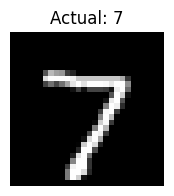

Predicted: 7
--------------------


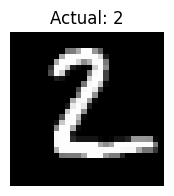

Predicted: 2
--------------------


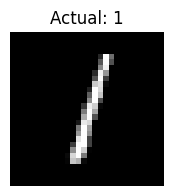

Predicted: 1
--------------------


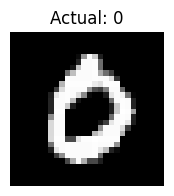

Predicted: 0
--------------------


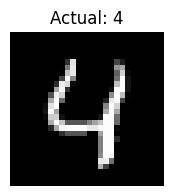

Predicted: 4
--------------------


In [12]:
import numpy as np
import matplotlib.pyplot as plt

for i in range(5):
    plt.figure(figsize=(2,2))
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {y_test[i]}")
    plt.axis('off')
    plt.show()

    prediction = model.predict(X_test[i].reshape(1,28,28,1), verbose=0)
    print("Predicted:", np.argmax(prediction))
    print("-" * 20)

In [13]:
model.save("digit_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [14]:
from google.colab import files

files.download("digit_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>